In [1]:
  # --- INSTALASI ---
!pip install pandas numpy matplotlib tensorflow keras scikit-learn openpyxl pmdarima

# --- BAGIAN 1: IMPORT ---=
import pandas as pd             # Alat untuk baca tabel data (Excel/CSV)
import numpy as np              # Alat untuk hitungan matematika
import matplotlib.pyplot as plt # Alat untuk menggambar grafik
import math
import sklearn.metrics as metrics
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error



# alat untuk mengubah angka besar (misal: Rp 1 Juta) jadi angka kecil (0-1)
# Biar komputernya tidak pusing hitung angka nol yang kebanyakan.
from sklearn.preprocessing import MinMaxScaler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.9 MB/s eta 0:00:00


In [2]:
#show data
path = "/content/sample_data/dataaa.xlsx"

df = pd.read_excel(path)

df.info()
df


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1853 entries, 0 to 1852
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Nomor        1853 non-null   object        
 1   Tanggal      1853 non-null   datetime64[ns]
 2   Pelanggan    1853 non-null   object        
 3   Tipe Barang  1853 non-null   object        
 4   Qty          1853 non-null   int64         
 5   Total        1853 non-null   float64       
 6   Sumber       1853 non-null   object        
 7   Notes        1853 non-null   object        
 8   Keterangan   1853 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 130.4+ KB


,Nomor,Tanggal,Pelanggan,Tipe Barang,Qty,Total,Sumber,Notes,Keterangan
0,SL/DKS/2024-0458,2024-03-01,"MARYANTI, IBU",CONWOOD,2,1609200.0,Intheria,REPEAT ORDER,End User
1,SL/DKS/2024-0462,2024-03-01,DGA INTERIOR,BALIAN WALL STORAGE,3,976800.0,Intheria,CS - WEBSITE,Konsultan
2,SL/DKS/2024-0460,2024-03-01,"ROBIN, BPK",BALIAN NAIL FREE,37,8330000.0,Intheria,WALK IN,End User
3,SL/DKS/2024-0527,2024-03-01,ILHAM APLIKATOR,BALIAN WALL STORAGE,3,840000.0,Intheria,REPEAT ORDER,Internal
4,SL/DKS/2024-0461,2024-03-02,"ROBIN, BPK",BALIAN WALL PANEL,45,10083200.0,Intheria,WALK IN,End User
...,...,...,...,...,...,...,...,...,...
1848,SI/MKDG/2025-02707,2025-09-09,"NANA, IBU",BALIAN WALL STORAGE,8,1948200.0,Sales,INTHERIA BANDUNG,End User
1849,SI/MKD/2025-3916,2025-09-10,"JADE LIVING INDONESIA, CV",BALIAN WALL STORAGE,30,6158240.0,Sales,REPEAT ORDER,Konsultan
1850,SL/DKS/2025-0073,2025-09-11,"SANDRA, IBU",Conwood,6,2484312.0,Intheria Bdg,WALK IN,End User
1851,SI/MKD/2025-3960,2025-09-12,"NICHO KONTRAKTOR, BPK",BALIAN WALL STORAGE,8,976500.0,Sales,REPEAT ORDER,Konsultan


In [3]:
#CLEANING DATA
print(df.columns.tolist())

df.columns = df.columns.str.strip().str.lower().str.replace(' ','_')

print("FIX APPLIED")
print(df.columns.tolist())

['Nomor', 'Tanggal', 'Pelanggan', 'Tipe Barang', 'Qty', 'Total', 'Sumber', 'Notes', 'Keterangan']
FIX APPLIED
['nomor', 'tanggal', 'pelanggan', 'tipe_barang', 'qty', 'total', 'sumber', 'notes', 'keterangan']


In [4]:
#date parsing
df['tanggal'] = pd.to_datetime(df['tanggal'])
print(df['tanggal'].dtype)

df = df.set_index('tanggal')

datetime64[ns]


In [5]:
df['tipe_barang'] = df['tipe_barang'].str.strip().str.lower().str.replace(' ','_')
print(df['tipe_barang'])

tanggal
2024-03-01                conwood
2024-03-01    balian_wall_storage
2024-03-01       balian_nail_free
2024-03-01    balian_wall_storage
2024-03-02      balian_wall_panel
                     ...         
2025-09-09    balian_wall_storage
2025-09-10    balian_wall_storage
2025-09-11                conwood
2025-09-12    balian_wall_storage
2025-09-12                conwood
Name: tipe_barang, Length: 1853, dtype: object


In [6]:
#cek transaksi kosong
transaksi_nol = df[df['total'] == 0]
jumlah_nol_asli = len(transaksi_nol)

print(f"Ada {jumlah_nol_asli} transaksi yang nilainya 0 rupiah di data asli")
if jumlah_nol_asli > 0:
    print("Contoh data 0 di asli:")
    print(transaksi_nol.head())

Ada 0 transaksi yang nilainya 0 rupiah di data asli


In [7]:
df_models = df[['tipe_barang','qty','total']].copy()
print(df_models)

                    tipe_barang  qty       total
tanggal                                         
2024-03-01              conwood    2   1609200.0
2024-03-01  balian_wall_storage    3    976800.0
2024-03-01     balian_nail_free   37   8330000.0
2024-03-01  balian_wall_storage    3    840000.0
2024-03-02    balian_wall_panel   45  10083200.0
...                         ...  ...         ...
2025-09-09  balian_wall_storage    8   1948200.0
2025-09-10  balian_wall_storage   30   6158240.0
2025-09-11              conwood    6   2484312.0
2025-09-12  balian_wall_storage    8    976500.0
2025-09-12              conwood    1    760500.0

[1853 rows x 3 columns]


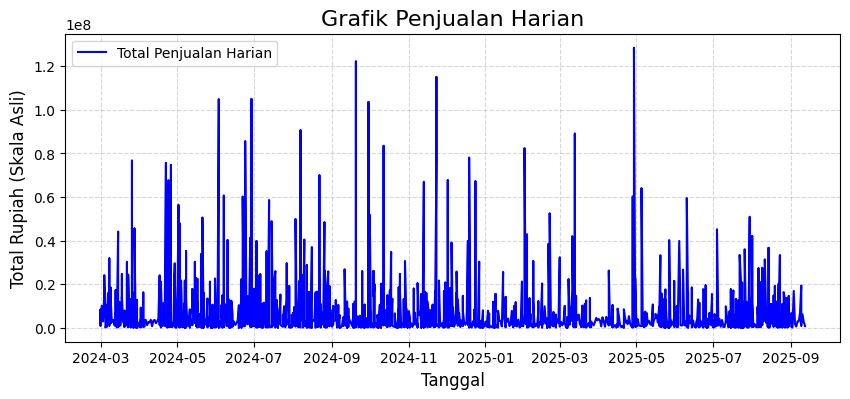

In [8]:
# Atur ukuran gambar biar lebar dan jelas
plt.figure(figsize=(10, 4))

# Plot data: Sumbu X = Tanggal, Sumbu Y = Total Penjualan
plt.plot(df_models.index, df_models['total'], label='Total Penjualan Harian', color='blue')

# Beri judul dan label
plt.title('Grafik Penjualan Harian', fontsize=16)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Total Rupiah (Skala Asli)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5) # Tambah garis bantu kotak-kotak

# Tampilkan
plt.show()

In [9]:
y = df_models['total']

print(y)
X = df.drop(columns=['total', 'nomor', 'pelanggan', 'sumber', 'notes', 'keterangan'])
print(X)

tanggal
2024-03-01     1609200.0
2024-03-01      976800.0
2024-03-01     8330000.0
2024-03-01      840000.0
2024-03-02    10083200.0
                 ...    
2025-09-09     1948200.0
2025-09-10     6158240.0
2025-09-11     2484312.0
2025-09-12      976500.0
2025-09-12      760500.0
Name: total, Length: 1853, dtype: float64
                    tipe_barang  qty
tanggal                             
2024-03-01              conwood    2
2024-03-01  balian_wall_storage    3
2024-03-01     balian_nail_free   37
2024-03-01  balian_wall_storage    3
2024-03-02    balian_wall_panel   45
...                         ...  ...
2025-09-09  balian_wall_storage    8
2025-09-10  balian_wall_storage   30
2025-09-11              conwood    6
2025-09-12  balian_wall_storage    8
2025-09-12              conwood    1

[1853 rows x 2 columns]


In [10]:
from sklearn.model_selection import train_test_split

train_size = int(len(df_models) * 0.8)
train_data = df_models.iloc[:train_size]
test_data = df_models.iloc[train_size:]

In [11]:
train_data = np.log1p(train_data['total'])
test_data = np.log1p(test_data['total'])
train_diff = train_data.diff().dropna()

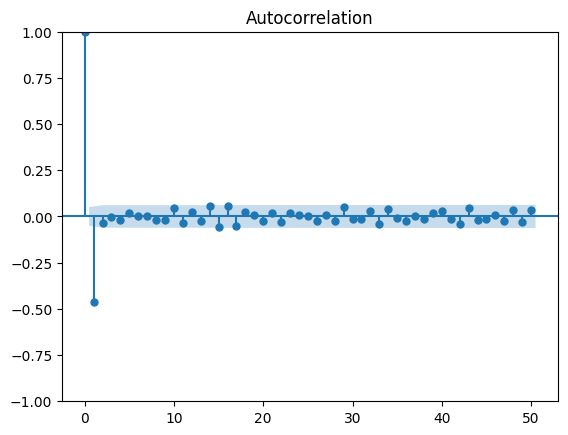

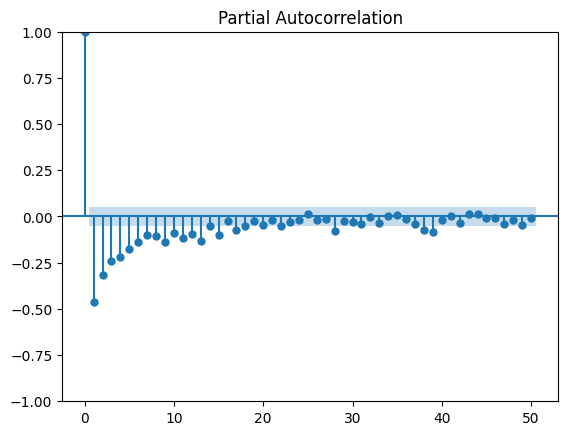

In [12]:
import statsmodels.api as sm

sm.graphics.tsa.plot_acf(train_diff, lags=50)
sm.graphics.tsa.plot_pacf(train_diff, lags=50)
plt.show()

In [13]:
y_train = train_diff.values
y_test = test_data.values

In [14]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train_diff)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -14.052794
p-value: 0.000000


In [15]:
auto_model = auto_arima(train_data, seasonal=True, m=4,
    start_p=0,
    start_q=0,
    max_p=5,
    max_q=5,
    seasonal_start_p=0,
    seasonal_start_q=0,
    seasonal_max_p=3,
    seasonal_max_q=3,
    trace=True,
    stepwise=False,
    suppress_warnings=True, n_jobs=-1)


Best model:  ARIMA(3,1,0)(2,0,0)[4] intercept
Total fit time: 191.819 seconds


In [16]:
sarima_model = SARIMAX(
    train_data,
    order=auto_model.order,
    seasonal_order=auto_model.seasonal_order,
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [17]:
sarima_result = sarima_model.fit()
sarima_pred= sarima_result.predict(
    start=len(train_diff),
    end=len(train_diff)+len(test_data)-1,
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [18]:
mae_sarima = mean_absolute_error(y_test, sarima_pred)
rmse_sarima = np.sqrt(mean_squared_error(y_test, sarima_pred))

print(f"MAE: {mae_sarima}")
print(f"RMSE: {rmse_sarima}")

MAE: 1.3171657679334858
RMSE: 1.6346861128554233


In [19]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_sarima = mean_absolute_percentage_error(y_test, sarima_pred)

In [20]:
print(f"SARIMA - MAPE : {mape_sarima}%")

SARIMA - MAPE : 9.656703310156484%


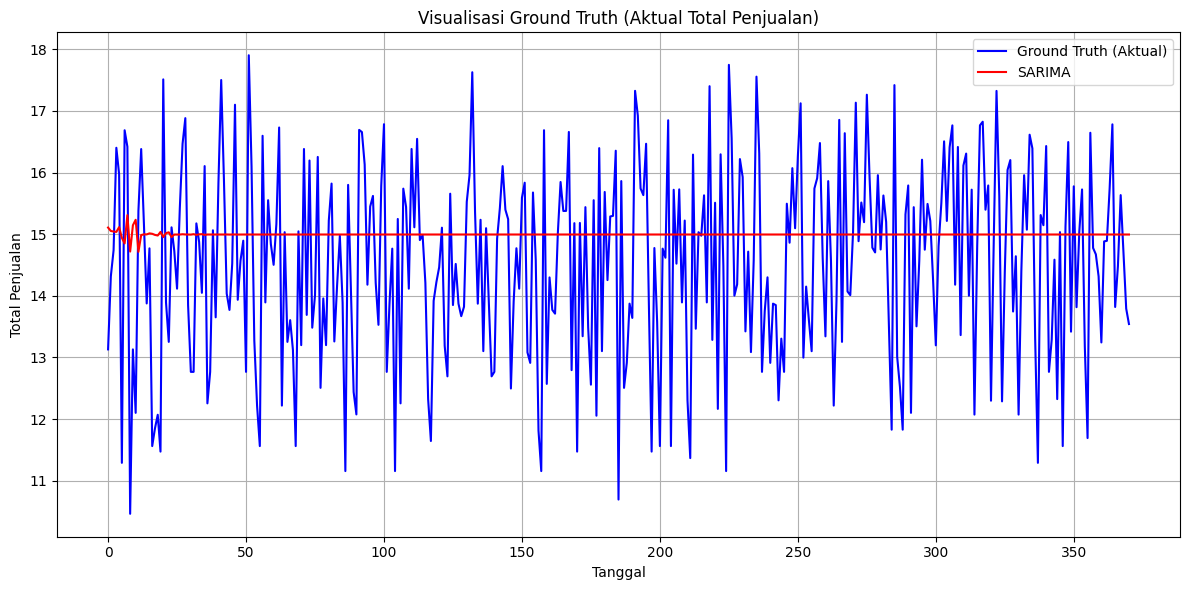

In [21]:
plt.figure(figsize=(12,6))
plt.plot(test_data.values, label='Ground Truth (Aktual)', color='blue')
plt.plot(sarima_pred.values, label='SARIMA', color='red')
plt.title('Visualisasi Ground Truth (Aktual Total Penjualan)')
plt.xlabel('Tanggal')
plt.ylabel('Total Penjualan')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()